In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Importing & Cleaning Data**

In [2]:
master = pd.read_csv(
    "master_f1_dataset.csv",
    dtype={"number": "string"}
)

In [6]:
master.drop(
    columns=[
        "resultId",
        "number",
        "positionText",
        "time",
        "milliseconds",
        "rank",
        "fastestLapSpeed"
    ],
    inplace=True
)

In [8]:
master["date"] = pd.to_datetime(master["date"])

In [10]:
master["date"].dtype

dtype('<M8[ns]')

In [7]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   raceId            26759 non-null  int64  
 1   driverId          26759 non-null  int64  
 2   constructorId     26759 non-null  int64  
 3   grid              26759 non-null  int64  
 4   position          26759 non-null  object 
 5   positionOrder     26759 non-null  int64  
 6   points            26759 non-null  float64
 7   laps              26759 non-null  int64  
 8   fastestLap        26759 non-null  object 
 9   fastestLapTime    26759 non-null  object 
 10  statusId          26759 non-null  int64  
 11  driver_name       26759 non-null  object 
 12  constructor       26759 non-null  object 
 13  year              26759 non-null  int64  
 14  round             26759 non-null  int64  
 15  circuitId         26759 non-null  int64  
 16  race_name         26759 non-null  object

# **Driver Performance Analysis**

####1.  **Top 10 Drivers by Wins - Which drivers have won the most Formula 1 races?**



In [3]:
drivers_wins = (
    master[master["winner"]]
    .groupby("driver_name")
    .size()
    .sort_values(ascending = False)
    .head(10)
)

drivers_wins

,0
driver_name,
Lewis Hamilton,105
Michael Schumacher,91
Max Verstappen,63
Sebastian Vettel,53
Alain Prost,51
Ayrton Senna,41
Fernando Alonso,32
Nigel Mansell,31
Jackie Stewart,27


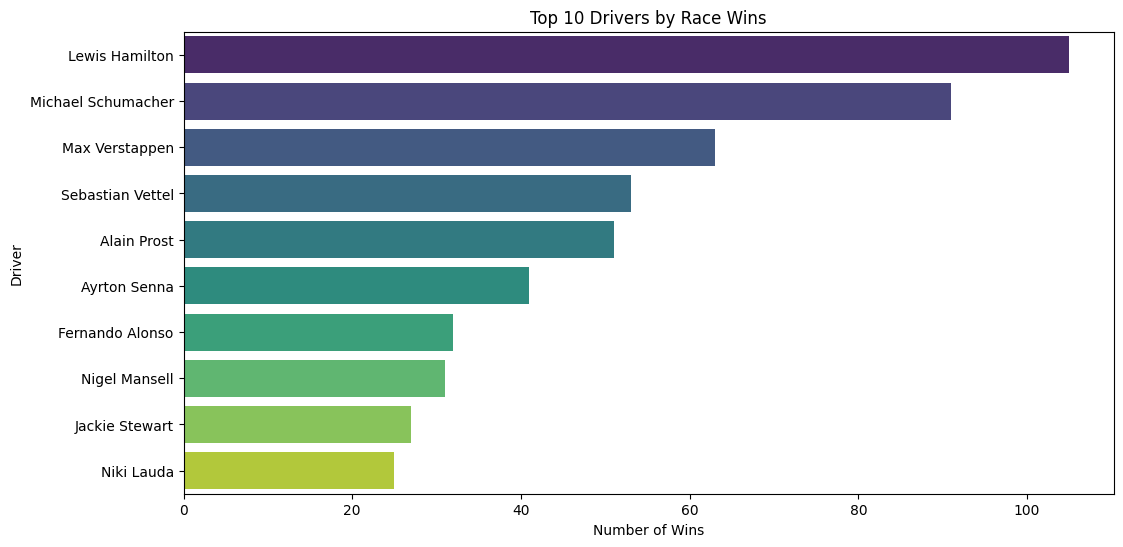

In [4]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=drivers_wins.values,
    y=drivers_wins.index,
    hue=drivers_wins.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Drivers by Race Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Driver")

plt.show()

Lewis Hamilton, Michael Schumacher, and Max Verstappen are among the most successful drivers in Formula 1 history. The chart highlights sustained excellence and dominance over multiple seasons.

####2.  **Top 10 Drivers by Podiums - Which drivers consistently finish in the top three?**



In [6]:
drivers_podiums = (
    master[master["podium"]]
    .groupby("driver_name")
    .size()
    .sort_values(ascending = False)
    .head(10)
)

drivers_podiums

,0
driver_name,
Lewis Hamilton,202
Michael Schumacher,155
Sebastian Vettel,122
Max Verstappen,112
Alain Prost,106
Fernando Alonso,106
Kimi Räikkönen,103
Ayrton Senna,80
Rubens Barrichello,68


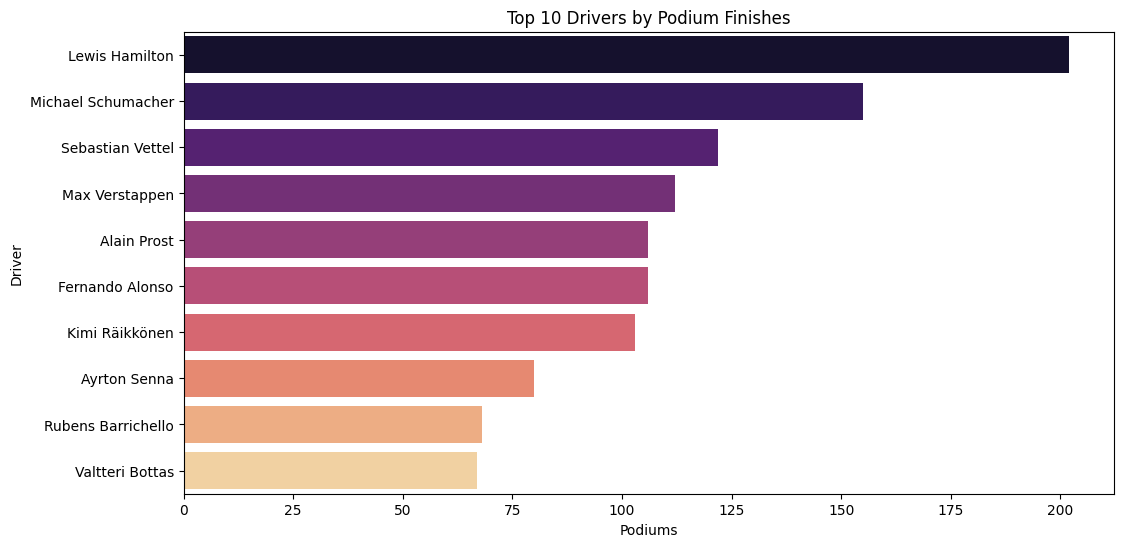

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=drivers_podiums.values,
    y=drivers_podiums.index,
    hue=drivers_podiums.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Drivers by Podium Finishes")
plt.xlabel("Podiums")
plt.ylabel("Driver")

plt.show()

Podium finishes are a strong indicator of consistency. Drivers with frequent podiums demonstrate competitive performance even when they do not win races.

####3.  **Top 10 Drivers by Total Points - Which drivers have accumulated the most championship points?**



In [9]:
driver_pts = (
    master.groupby("driver_name")["points"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
)

driver_pts

,points
driver_name,
Lewis Hamilton,4820.5
Sebastian Vettel,3098.0
Max Verstappen,2912.5
Fernando Alonso,2329.0
Kimi Räikkönen,1873.0
Valtteri Bottas,1788.0
Nico Rosberg,1594.5
Sergio Pérez,1585.0
Michael Schumacher,1566.0


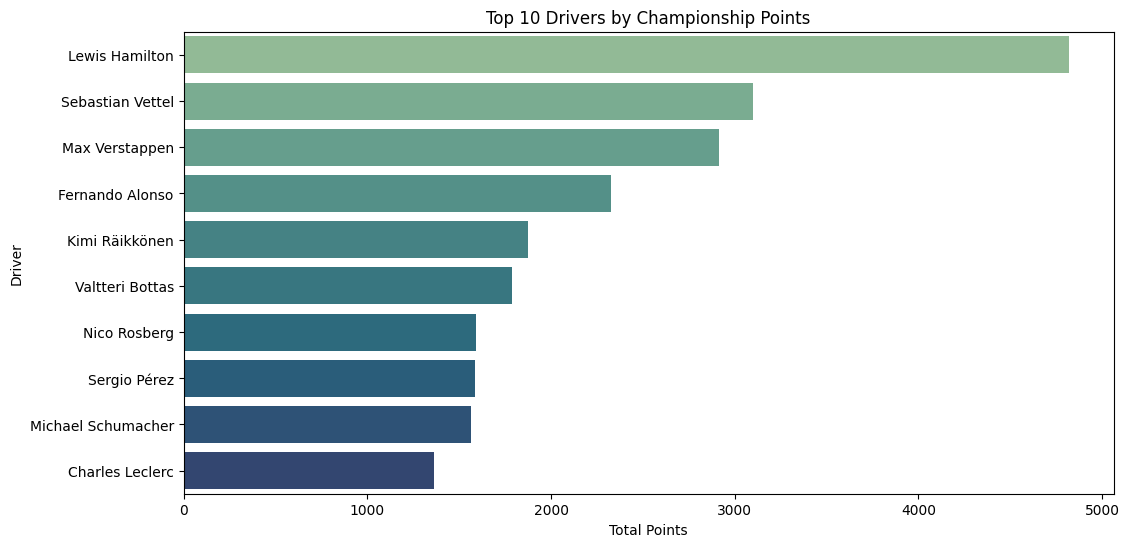

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=driver_pts.values,
    y=driver_pts.index,
    hue=driver_pts.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Drivers by Championship Points")
plt.xlabel("Total Points")
plt.ylabel("Driver")

plt.show()

Total championship points reflect long-term performance and reliability. Drivers who consistently score points tend to remain championship contenders over several seasons.

# **Constructor Performance Analysis**

####1. **Top 10 Constructors by Race Wins - Which Formula 1 constructors have won the most races?**

In [15]:
constructor_wins = (
    master[master["winner"]]
    .groupby("constructor")
    .size()
    .sort_values(ascending = False)
    .head(10)
)

constructor_wins

,0
constructor,
Ferrari,249
McLaren,185
Mercedes,129
Red Bull,122
Williams,114
Team Lotus,45
Renault,35
Benetton,27
Tyrrell,23


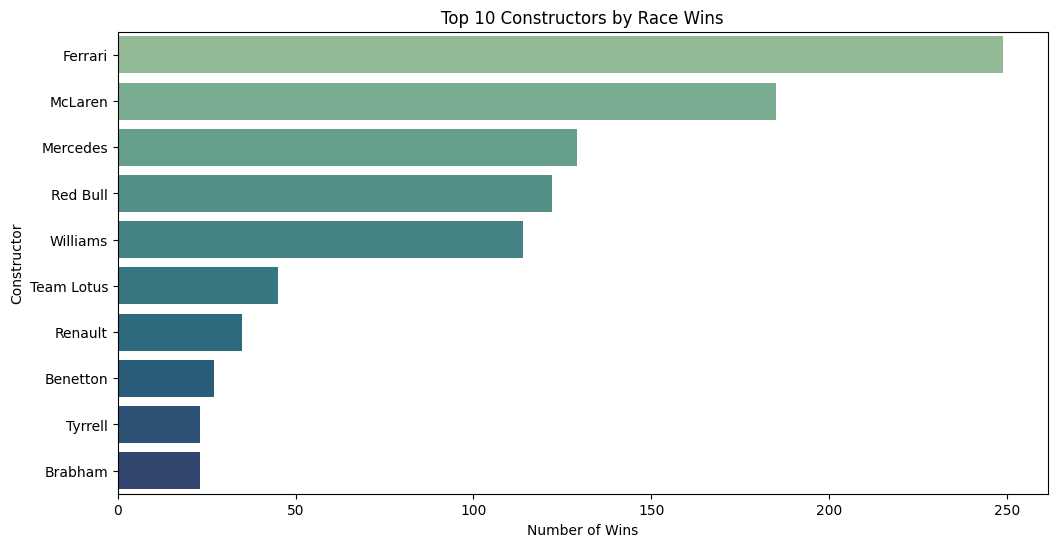

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=constructor_wins.values,
    y=constructor_wins.index,
    hue=constructor_wins.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Constructors by Race Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Constructor")

plt.show()

Ferrari, McLaren, Mercedes, and Red Bull Racing have secured the highest number of race victories, reflecting their long-standing competitiveness and success across multiple Formula 1 seasons.

####2. **Top 10 Constructors by Championship Points - Which constructors have accumulated the most championship points?**

In [17]:
constructor_pts = (
    master.groupby("constructor")["points"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
)

constructor_pts

,points
constructor,
Ferrari,11091.27
Mercedes,7730.64
Red Bull,7673.00
McLaren,7022.50
Williams,3641.00
Renault,1777.00
Force India,1098.00
Team Lotus,995.00
Benetton,861.50


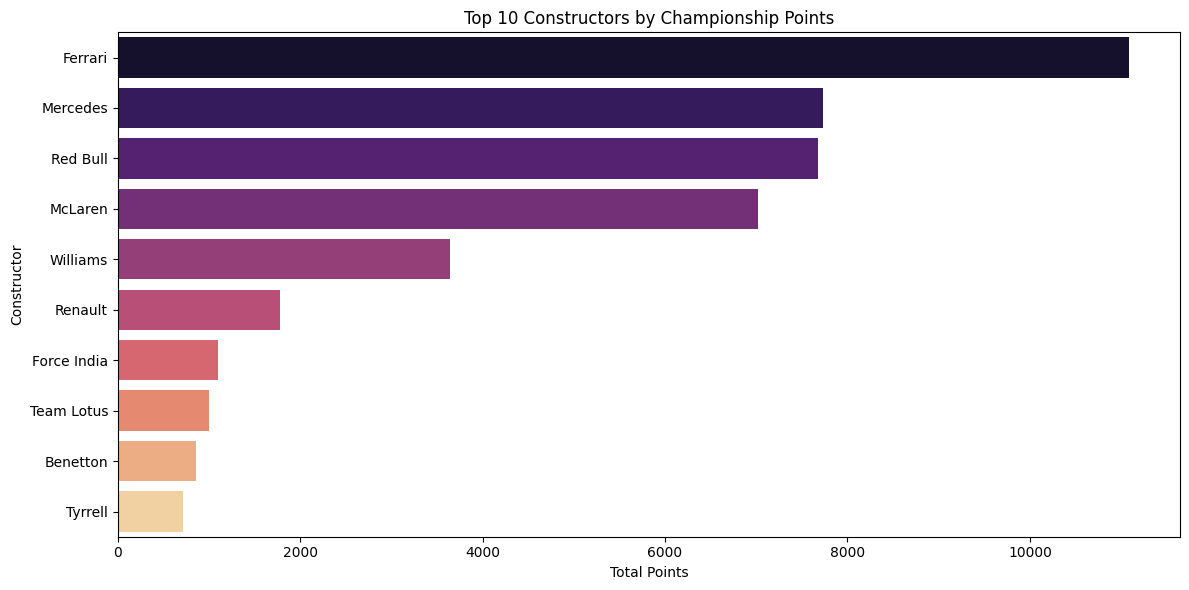

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=constructor_pts.values,
    y=constructor_pts.index,
    hue=constructor_pts.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Constructors by Championship Points")
plt.xlabel("Total Points")
plt.ylabel("Constructor")

plt.tight_layout()
plt.show()

####3. **Constructor Win Percentage - Which constructors have the highest win percentage?**

In [21]:
constructor_stats = (
    master.groupby("constructor")
    .agg(
        total_races = ("raceId", "count"),
        wins = ("winner", "sum")
    )
)

constructor_stats["win_percentage"] = (
    constructor_stats["wins"] / constructor_stats["total_races"]
) * 100

constructor_stats = (
    constructor_stats[constructor_stats["total_races"] >= 50]
    .sort_values("win_percentage", ascending = False)
    .head(10)
)

constructor_stats

,total_races,wins,win_percentage
constructor,,,
Mercedes,652,129,19.785276
Red Bull,788,122,15.482234
Vanwall,71,10,14.084507
Brabham-Repco,77,8,10.389610
Ferrari,2439,249,10.209102
McLaren,1923,185,9.620385
Lotus-Climax,233,22,9.442060
Lotus-Ford,128,11,8.593750
Williams,1676,114,6.801909


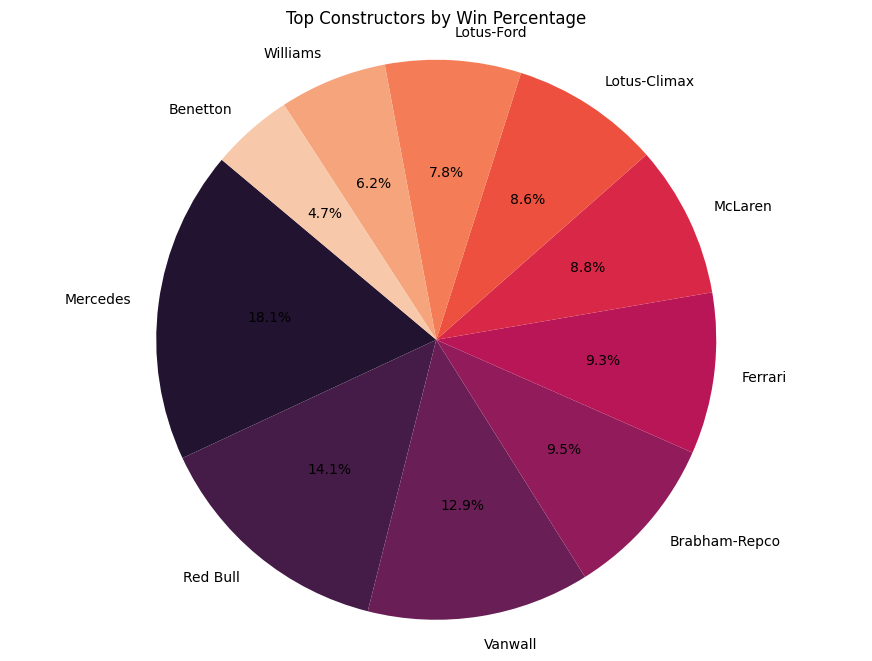

In [30]:
plt.figure(figsize=(11, 8))

plt.pie(
    constructor_stats["win_percentage"],
    labels=constructor_stats.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("rocket", len(constructor_stats))
)

plt.title("Top Constructors by Win Percentage")
plt.axis("equal")

plt.show()

Win percentage highlights efficiency rather than longevity. Teams with a high percentage convert a larger share of race entries into victories.

####4. **Most Reliable Constructors - Which constructors finish races most consistently?**

In [25]:
reliability = (
    master.groupby("constructor")
    .agg(
        total_entries=("raceId", "count"),
        finished=("finished", "sum")
    )
)

reliability["finish_rate"] = (
    reliability["finished"] /
    reliability["total_entries"]
) * 100

reliability = (
    reliability[reliability["total_entries"] >= 50]
    .sort_values("finish_rate", ascending=False)
    .head(10)
)

reliability

,total_entries,finished,finish_rate
constructor,,,
Mercedes,652,534,81.901840
Red Bull,788,568,72.081218
BMW Sauber,140,92,65.714286
Aston Martin,191,106,55.497382
Alpine F1 Team,180,99,55.000000
Ferrari,2439,1322,54.202542
McLaren,1923,991,51.534061
Lotus F1,154,79,51.298701
AlphaTauri,166,83,50.000000


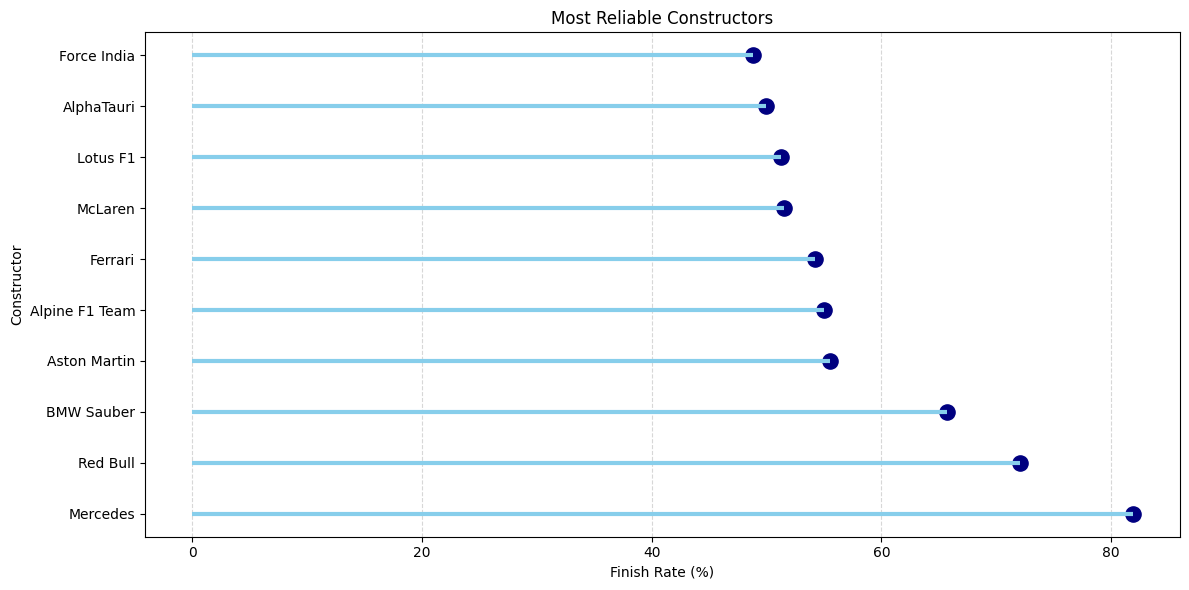

In [33]:
plt.figure(figsize=(12,6))

plt.hlines(
    y=reliability.index,
    xmin=0,
    xmax=reliability["finish_rate"],
    color="skyblue",
    linewidth=3
)

plt.scatter(
    reliability["finish_rate"],
    reliability.index,
    color="navy",
    s=120
)

plt.title("Most Reliable Constructors")
plt.xlabel("Finish Rate (%)")
plt.ylabel("Constructor")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Reliability plays a crucial role in championship success. Constructors with high finish rates are more likely to score points consistently throughout a season.

# **Race Performance Analysis**

####1. **Grid Position vs Finish Position - Does qualifying position influence the final race result?**

In [34]:
master[["grid", "positionOrder"]].head()

,grid,positionOrder
0,1,1
1,5,2
2,7,3
3,11,4
4,3,5


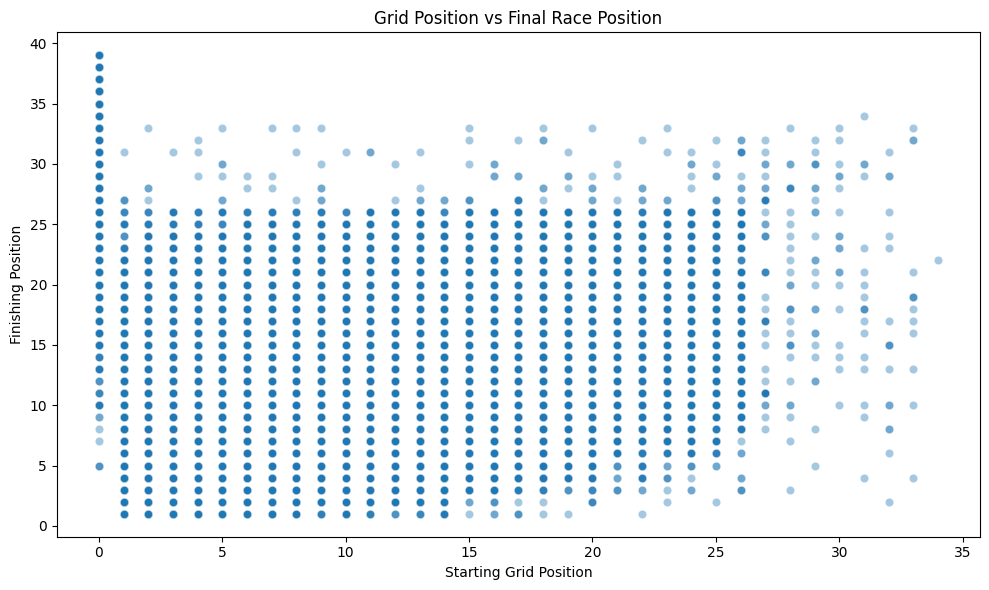

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master,
    x="grid",
    y="positionOrder",
    alpha=0.4
)

plt.title("Grid Position vs Final Race Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Finishing Position")

plt.tight_layout()
plt.show()

Drivers starting closer to the front generally finish in better positions. However, the spread of points shows that overtakes, strategy, weather, and reliability can significantly alter race outcomes.

####2. **Average Finish by Grid Position - How does the starting grid position affect the average finishing position?**

In [40]:
avg_finish = (
    master[master["grid"] > 0]
    .groupby("grid")["positionOrder"]
    .mean()
    .reset_index()
)

avg_finish.head()

,grid,positionOrder
0,1,5.663732
1,2,6.611556
2,3,7.505310
3,4,8.231449
4,5,9.136042


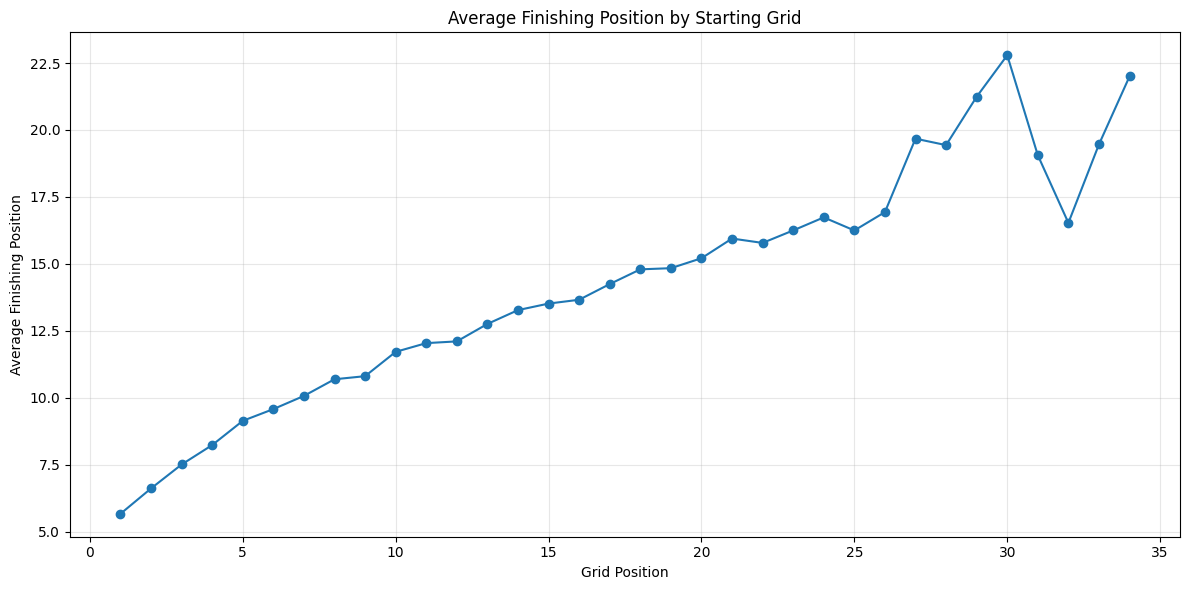

In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    avg_finish["grid"],
    avg_finish["positionOrder"],
    marker="o"
)

plt.title("Average Finishing Position by Starting Grid")
plt.xlabel("Grid Position")
plt.ylabel("Average Finishing Position")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The trend generally rises from left to right, showing that drivers who start further back usually finish further back. Lower grid positions provide a competitive advantage but do not guarantee victory.

####3. **Pole Position Conversion - How often does starting from pole position lead to victory?**

In [42]:
pole_conversion = (
    master[master["pole_position"]]
    .groupby("winner")
    .size()
)

pole_conversion

,0
winner,
False,655
True,481


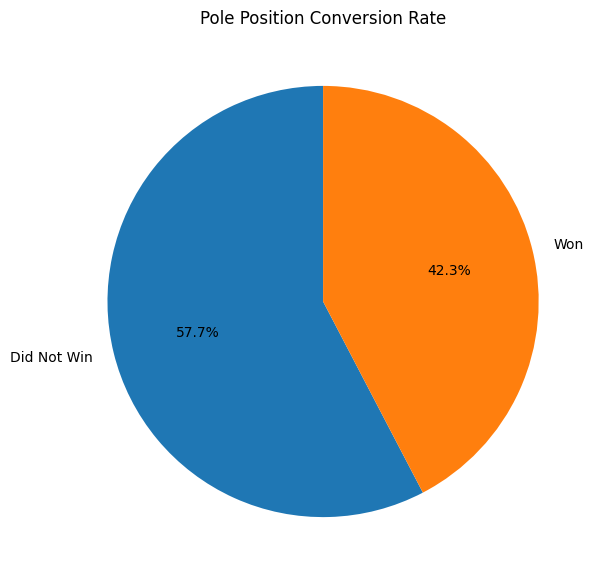

In [43]:
plt.figure(figsize=(7,7))

plt.pie(
    pole_conversion.values,
    labels=["Did Not Win", "Won"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Pole Position Conversion Rate")

plt.show()

Starting from pole position improves the chances of winning, but it does not guarantee success. Race strategy, tyre management, and reliability still play crucial roles.

####4. **Top Circuits by Number of Races - Which Formula 1 circuits have hosted the most Grands Prix?**

In [47]:
top_circuits = (
    master.groupby("circuit")
    .agg(races = ("raceId", "nunique"))
    .sort_values("races", ascending = False)
    .head(10)
)

top_circuits

,races
circuit,
Autodromo Nazionale di Monza,74
Circuit de Monaco,70
Silverstone Circuit,59
Circuit de Spa-Francorchamps,57
Circuit Gilles Villeneuve,43
Autódromo José Carlos Pace,41
Nürburgring,41
Hungaroring,39
Red Bull Ring,38


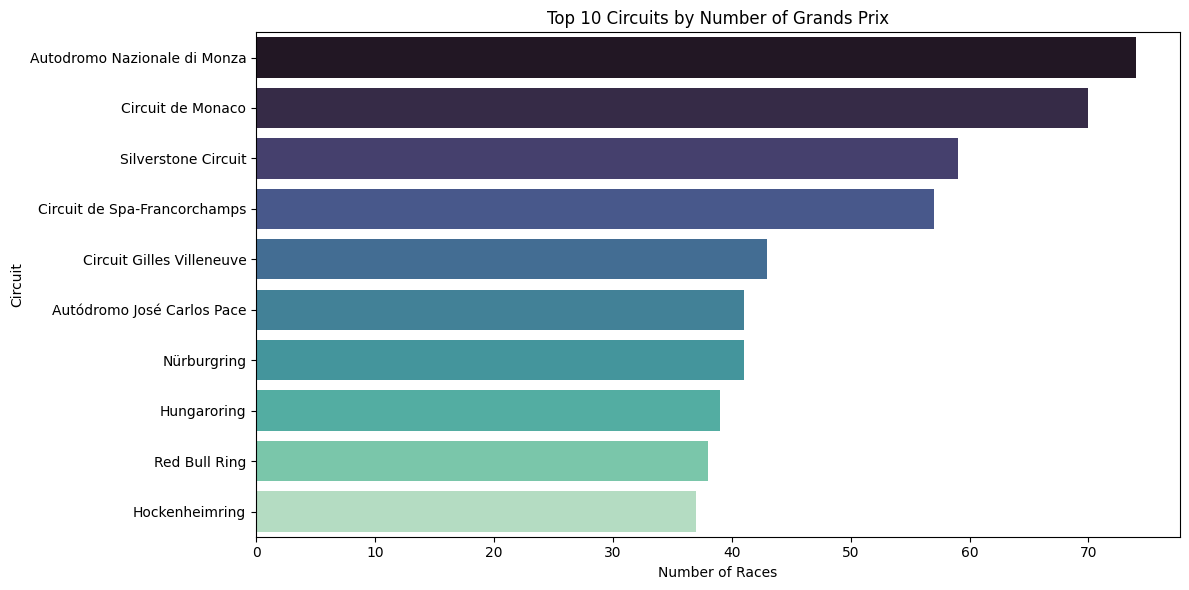

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_circuits,
    x="races",
    y=top_circuits.index,
    hue=top_circuits.index,
    palette="mako",
    legend=False
)

plt.title("Top 10 Circuits by Number of Grands Prix")
plt.xlabel("Number of Races")
plt.ylabel("Circuit")

plt.tight_layout()
plt.show()

Historic venues such as Monza, Silverstone, and Monaco appear among the most frequently used circuits, reflecting their long-standing importance in the Formula 1 calendar.